In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Loading dataset

In [2]:
# load dataset
df = pd.read_csv('boston_housing.csv', low_memory=False)
print(df.head())
print(len(df))

   _id        PID  CM_ID     GIS_ID  ST_NUM  ST_NUM2       ST_NAME UNIT_NUM  \
0    1  100001000    NaN  100001000   195.0      NaN  Lexington ST      NaN   
1    2  100002000    NaN  100002000   197.0      NaN  Lexington ST      NaN   
2    3  100003000    NaN  100003000   199.0      NaN  Lexington ST      NaN   
3    4  100004000    NaN  100004000   201.0      NaN  Lexington ST      NaN   
4    5  100005000    NaN  100005000   203.0      NaN  Lexington ST      NaN   

          CITY  ZIP_CODE  ...     KITCHEN_STYLE2   KITCHEN_STYLE3  \
0  EAST BOSTON    2128.0  ...    S - Semi-Modern  S - Semi-Modern   
1  EAST BOSTON    2128.0  ...         M - Modern       M - Modern   
2  EAST BOSTON    2128.0  ...    S - Semi-Modern  S - Semi-Modern   
3  EAST BOSTON    2128.0  ...    S - Semi-Modern  S - Semi-Modern   
4  EAST BOSTON    2128.0  ...  N - No Remodeling  S - Semi-Modern   

            HEAT_TYPE HEAT_SYSTEM         AC_TYPE FIREPLACES ORIENTATION  \
0  W - Ht Water/Steam         NaN 

# Data Cleaning

Since our target feature would be total_value or sfyi_value or land_value, we should drop all rows with NaN values for target feature

In [3]:
for col in ['LAND_VALUE', 'BLDG_VALUE', 'SFYI_VALUE', 'TOTAL_VALUE']:
    vals = pd.to_numeric(df[col], errors='coerce')
    print(f"{col}: missing={vals.isna().sum()} ({vals.isna().mean():.1%}), sample={vals.dropna().head(3).tolist()}")

LAND_VALUE: missing=87395 (47.4%), sample=[0.0, 0.0, 0.0]
BLDG_VALUE: missing=161743 (87.6%), sample=[0.0, 0.0, 0.0]
SFYI_VALUE: missing=7758 (4.2%), sample=[0.0, 0.0, 0.0]
TOTAL_VALUE: missing=173324 (93.9%), sample=[0.0, 0.0, 0.0]


In [4]:
for col in ['LAND_VALUE', 'BLDG_VALUE', 'SFYI_VALUE', 'TOTAL_VALUE']:
    vals = pd.to_numeric(df[col], errors='coerce')
    non_zero = (vals > 0).sum()
    zero = (vals == 0).sum()
    print(f"{col}: non-zero={non_zero} ({non_zero/len(df):.1%}), zero={zero}, missing={vals.isna().sum()}")

LAND_VALUE: non-zero=89 (0.0%), zero=97068, missing=87395
BLDG_VALUE: non-zero=2622 (1.4%), zero=20187, missing=161743
SFYI_VALUE: non-zero=623 (0.3%), zero=176171, missing=7758
TOTAL_VALUE: non-zero=82 (0.0%), zero=11146, missing=173324


~90% missing values for a housing dataset doesn't make sense, the target features are probably strings

In [5]:
for col in ['TOTAL_VALUE', 'LAND_VALUE']:
    print(f"{col}: dtype={df[col].dtype}, sample type={type(df[col].iloc[0])}")

TOTAL_VALUE: dtype=str, sample type=<class 'str'>
LAND_VALUE: dtype=str, sample type=<class 'str'>


Yes, values are strings in building value type columns

### Converting target feature values to numeric dtype

In [6]:
value_cols = ['LAND_VALUE', 'BLDG_VALUE', 'SFYI_VALUE', 'TOTAL_VALUE']

for col in value_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')
    print(f"{col}: non-null={df[col].notna().sum()}, zeros={(df[col]==0).sum()}, mean={df[col][df[col]>0].mean():,.0f}")

LAND_VALUE: non-null=184552, zeros=97068, mean=816,263
BLDG_VALUE: non-null=184551, zeros=20187, mean=1,297,197
SFYI_VALUE: non-null=184552, zeros=176171, mean=67,205
TOTAL_VALUE: non-null=184552, zeros=11146, mean=1,644,613


In [7]:
for col in value_cols:
    total = len(df)
    null_pct  = df[col].isna().mean() * 100
    zero_pct  = (df[col] == 0).mean() * 100
    valid_pct = (df[col] > 0).mean() * 100
    print(f"{col}: NaN={null_pct:.2f}%  zero={zero_pct:.2f}%  valid(>0)={valid_pct:.2f}%")

LAND_VALUE: NaN=0.00%  zero=52.60%  valid(>0)=47.40%
BLDG_VALUE: NaN=0.00%  zero=10.94%  valid(>0)=89.06%
SFYI_VALUE: NaN=0.00%  zero=95.46%  valid(>0)=4.54%
TOTAL_VALUE: NaN=0.00%  zero=6.04%  valid(>0)=93.96%


### Total_value should clearly be the target feature - most rows have values, dropping rows with total_value = 0

In [8]:
before = len(df)
df = df[df['TOTAL_VALUE'] > 0].reset_index(drop=True)
print(f"Dropped: {before - len(df)} rows")
print(f"Remaining: {len(df)}")

Dropped: 11146 rows
Remaining: 173406


In [9]:
missing = df.isna().sum() / len(df) * 100
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing value percentage per feature")
print(missing.round(2).to_string(float_format=lambda x: f'{x:.2f}%'))

Missing value percentage per feature
RES_UNITS             100.00%
RC_UNITS              100.00%
COM_UNITS             100.00%
KITCHEN_STYLE3         91.92%
STRUCTURE_CLASS        89.95%
ST_NUM2                88.51%
MAIL_ADDRESSEE         81.93%
KITCHEN_STYLE2         81.81%
BTHRM_STYLE3           77.93%
BDRM_COND              57.29%
CD_FLOOR               57.19%
ORIENTATION            57.04%
HEAT_SYSTEM            57.03%
CORNER_UNIT            57.03%
CM_ID                  51.02%
UNIT_NUM               50.97%
BTHRM_STYLE2           49.23%
YR_REMODEL             48.62%
TT_RMS                 21.82%
BED_RMS                21.78%
AC_TYPE                21.78%
HEAT_TYPE              21.77%
INT_WALL               21.77%
INT_COND               21.77%
PROP_VIEW              21.70%
KITCHEN_TYPE           21.68%
NUM_PARKING            21.68%
KITCHEN_STYLE1         21.68%
BTHRM_STYLE1           21.67%
ROOF_STRUCTURE         20.72%
ROOF_COVER             20.72%
EXT_COND               20.69%
RES

## Features with >75% missing values

Based on missing value percentage we can clearly drop features (over 75% missing values)-
1. RC_UNITS: 100% missing, no signal
2. COM_UNITS: 100% missing, no signal
3. RES_UNITS: 100% missing, no signal
4. STRUCTUE_CLASS: 89.95% missing, no signal
5. ST_NUM2: 88.51% missing, no signal
6. MAIL_ADDRESSE: 81.93% missing, no signal

Note - Even though KITCHEN_STYLE3, KITCHEN_STYLE2, and BTHRM_STYLE3 also have over 50% missing values,
this is not a data collection gap, some houses might be single bathroom/single kitchen and hence have no
value for KITCHEN_STYLE2, KITCHEN_STYLE3, or BTHRM_STYLE3, (to be explored)

In [10]:
print("Dropping invalid features with ~80% missing values")
cols_to_drop = [
    # >80% missing, no signal
    'RC_UNITS', 'COM_UNITS', 'RES_UNITS', 'STRUCTURE_CLASS', 'ST_NUM2', 'MAIL_ADDRESSEE',
    # unique identifiers — no predictive value
    '_id', 'PID', 'GIS_ID', 'OWNER', 'MAIL_STREET_ADDRESS'
]
df = df.drop(columns=cols_to_drop)
print(f'Remaining columns: {len(df.columns)}' + '\n\n\n')

Dropping invalid features with ~80% missing values
Remaining columns: 56





## Features with 50-75% missing values

Remaining features with high missing value percentage (50%>) -
1. BDRM_COND             57.29%
2. CD_FLOOR              57.19%
3. ORIENTATION           57.04%
4. CORNER_UNIT           57.03%
5. HEAT_SYSTEM           57.03%
6. UNIT_NUM              53.93%

### BDRM_COND

In [11]:
print(df['BDRM_COND'].unique())

<StringArray>
[nan, 'A - Average', 'G - Good', 'F - Fair', 'P - Poor', 'E - Excellent']
Length: 6, dtype: str


In [12]:
missing_by_type = df[df['BDRM_COND'].isna()]['BLDG_TYPE'].value_counts()
total_missing = missing_by_type.sum()
print((missing_by_type / total_missing * 100).round(2).to_string(float_format=lambda x: f'{x:.2f}%'))

BLDG_TYPE
CL - Colonial                        17.48%
CV - Conventional                    13.49%
NoBld                                11.32%
99 - Vacant                           8.09%
DK - Decker                           7.68%
TF - Two Fam Stack                    6.28%
RM - Row Middle                       3.89%
CP - Cape                             3.82%
SD - Semi-Det                         3.75%
111 - APT 4-6 UNITS                   3.19%
112 - APT 7-30 UNITS                  2.01%
RN - Ranch                            1.97%
RE - Row End                          1.85%
MR - Mid Rise                         1.16%
BW - Bungalow                         1.11%
DX - Duplex                           0.93%
RR - Raised Ranch                     0.88%
HR - High Rise                        0.68%
319 - STRIP RETAIL/ OFFICE            0.57%
125 - SUBSD HOUSING S- 8              0.52%
320 - RET/WHSL/SERVICE                0.49%
344 - OFFICE 3-9 STORY                0.46%
LR - Low Rise         

We have missing values in residential type buildings, but some non-residential type buildings (studios, labs) have BDRM_COND value as not NaN, this is likely an error in data collection as these should have been NaN or N/A. We need to explore this. The feature LU (Land use) describes what the building is used for, we can derive a feature IS_RES (Is residential) from this

In [13]:
unique_lu_desc = sorted(df['LU_DESC'].dropna().unique())
print(f"Total unique LU_DESC values: {len(unique_lu_desc)}\n")
print('\n'.join(unique_lu_desc))
# If output is still truncated in notebook, write to file
with open('lu_desc_unique.txt', 'w') as f:
    f.write('\n'.join(unique_lu_desc))
print("Written to lu_desc_unique.txt")

Total unique LU_DESC values: 192

ACTIVITY/ Social Center
ADMINISTRATIVE BLDG
AIR FREIGHT TERMINAL
AIR RIGHTS PROPERTY
APARTMENT BLDG
APT 100+ UNITS
APT 31-99 UNITS
APT 4-6 UNITS
APT 7-30 UNITS
ARMORY (MILITARY)
ARTIST STUDIO
ASSISTED LIVING/ Elderly
ATHLETIC /SPORTS CTR
AUDITORIUM /THEATER
AUDITORIUM/Sport Center
AUTO SALVAGE YARD
AUTO SUPPLY/Service
BANK ATM
BANK BUILDING
BAR/TAVERN/PUB
BOAT HOUSE /MARINA
BOAT REPAIR/ Storage
BOS HOUSING AUTHOR
BOST REDEVELOP AUTH
BOTTLING PLANT
BOWLING ALLEY
CAR WASH
CELL CARRIER
CEMETERY
CHARITABLE Organization
CHURCH, SYNAGOGUE
CITY OF BOSTON
CLASSROOM
COLD STORAGE WHSE
COLLEGE (academic)
COM BILLBOARD
COM GREENHOUSE
COM LAND (Secondary)
COM LAND (Unusable)
COM Underwater Land
COMM  CONDO
COMM MULTI-USE
COMM PKG GARAGE
COMMERCIAL LAND
COMPUTER /SCIENCE LAB
COMPUTER EQUIP BLDG
CONDO PARKING (COM)
CONDO PARKING (RES)
CONDO STORAGE (RES)
CONVENTION CTR/HOTEL
CORRECTIONAL BLDG
Com Utility Bldg /Shed
Commonwealth of Mass
DAIRY
DAY CARE
DAY CARE CENTER


In [14]:
lu_to_desc = df.groupby('LU')['LU_DESC'].unique().apply(sorted)

with open('lu_desc_groups.txt', 'w') as f:
    for lu, descs in sorted(lu_to_desc.items()):
        f.write(f'\n{lu}:\n')
        for d in descs:
            f.write(f'  {d}\n')

print('Written to lu_desc_groups.txt')

Written to lu_desc_groups.txt


#### Manual Analysis of lu_desc_groups -

| LU Code | Classification | Key LU_DESC Values | Notes |
|---------|---------------|-------------------|-------|
| A | Residential | APT 4-6 through 100+ UNITS, LUXURY APARTMENT, ROOMING HOUSE, SUBSD HOUSING, DORMITORY, ELDERLY HOME | Contains one outlier: DAY CARE CENTER |
| CD | Residential | RESIDENTIAL CONDO, CONDO STORAGE (RES) | |
| CM | Residential | CONDO MAIN | |
| R1 | Residential | SINGLE FAM DWELLING, MOBILE HOME | |
| R2 | Residential | TWO-FAM DWELLING | |
| R3 | Residential | THREE-FAM DWELLING, MULTIPLE BLDGS/1 LOT | |
| R4 | Residential | APT 4-6 UNITS | |
| RC | Residential | RES/COMMERCIAL USE, COMM MULTI-USE | |
| RL | Residential (land only) | RESIDENTIAL LAND | No structures — BDRM_COND structurally missing |
| RL-RL | Residential (land only) | RESIDENTIAL LAND, RES LAND (Secondary/Unusable), RES ANCILL IMPROVEMT | No structures — BDRM_COND structurally missing |
| AH | Non-Residential | PRDWOOD | Agricultural/hardwood land |
| C | Non-Residential | Restaurants, offices, retail, hotels, banks, hospitals, warehouses | Commercial |
| CC | Non-Residential | COMM CONDO, OFFICE CONDO, RETAIL CONDO, INDUSTR CONDO, CONDO PARKING (COM) | Commercial condos |
| CL | Non-Residential | COMMERCIAL LAND, INDUSTRIAL LAND, PARKING LOT | Land parcels only |
| CP | Non-Residential | CONDO PARKING (RES) | Parking ancillary to residential — no living space |
| EA | Non-Residential | EXEMPT 121A PROP | Tax-exempt commercial/development |
| I | Non-Residential | AUTO SALVAGE YARD, DAIRY, ELEC POWER PLANT, METAL PROCESSING, MANUFACTURING | Industrial |
| E | Mixed | APARTMENT BLDG, ASSISTED LIVING, BOS HOUSING AUTHOR, DORMITORY, RESIDENTIAL CONDO exmp + SCHOOL, HOSPITAL, CHURCH, GOV'T OFFICE, LIBRARY | Tax-exempt — needs row-level LU_DESC classification |


#### We have two LU types which are residential, but they don't contain bedrooms. Checking the total percentage of data that is RL and RL-RL so we can see if we should create a separate category for them or fit them into not_residential (since they would have missing BDRM_COND and other NaN values for bathroom and kitchen)

In [15]:
rl_mask = df['LU'].isin(['RL', 'RL - RL'])
print(f"RL:       {(df['LU'] == 'RL').sum()}")
print(f"RL - RL:  {(df['LU'] == 'RL - RL').sum()}")
print(f"Total:    {rl_mask.sum()} ({rl_mask.mean():.2%} of dataset)")

RL:       1
RL - RL:  5854
Total:    5855 (3.38% of dataset)


#### Creating IS_RES feature

These are the suspected outliers we need to keep in mind -
| LU | LU_DESC | Current | Should Be |
|----|---------|---------|-----------|
| A | RES PARKING GARAGE | 1 (Residential) | 0 (Non-residential) |
| A | RES PARKING LOT | 1 (Residential) | 0 (Non-residential) |
| A | DAY CARE CENTER | 1 (Residential) | 0 (Non-residential) |
| CD | CONDO STORAGE (RES) | 1 (Residential) | 0 (Non-residential) |
| C | NURSING /CONV HOME | 0 (Non-residential) | 0 (Non-residential) — confirmed, no BDRM_COND present |
| RC | COMM MULTI-USE | 1 (Residential) | 0 (Non-residential) — commercial portion of mixed-use buildings |

RC was classified as residential at the LU code level, but contains two LU_DESC types: `RES /COMMERCIAL USE` (residential) and `COMM MULTI-USE` (non-residential). The latter was caught during TT_RMS analysis when overlap rows with no bedroom/kitchen/bathroom data revealed commercial BLDG_TYPEs under IS_RES=1.

No bedrooms in 'NURSING/CONV HOME', so we put it under non-residential

In [16]:
outliers = [
    ('A',  'DAY CARE CENTER'),
    ('A',  'RES PARKING GARAGE'),
    ('A',  'RES PARKING LOT'),
    ('CD', 'CONDO STORAGE (RES)'),
    ('C',  'NURSING /CONV HOME'),
    ('RC', 'COMM MULTI-USE'),
]

for lu, desc in outliers:
    mask = (df['LU'] == lu) & (df['LU_DESC'] == desc)
    total   = mask.sum()
    present = df.loc[mask, 'BDRM_COND'].notna().sum()
    missing = df.loc[mask, 'BDRM_COND'].isna().sum()
    print(f"{lu} — {desc}: total={total}, present={present}, missing={missing}")

A — DAY CARE CENTER: total=23, present=0, missing=23
A — RES PARKING GARAGE: total=11, present=0, missing=11
A — RES PARKING LOT: total=25, present=0, missing=25
CD — CONDO STORAGE (RES): total=15, present=0, missing=15
C — NURSING /CONV HOME: total=16, present=0, missing=16
RC — COMM MULTI-USE: total=633, present=0, missing=633


| LU | LU_DESC | Current | Should Be |
|----|---------|---------|-----------|
| A | RES PARKING GARAGE | 1 (Residential) | 0 (Non-residential) |
| A | RES PARKING LOT | 1 (Residential) | 0 (Non-residential) |
| A | DAY CARE CENTER | 1 (Residential) | 0 (Non-residential) |
| CD | CONDO STORAGE (RES) | 1 (Residential) | 0 (Non-residential) |
| C | NURSING /CONV HOME | 0 (Non-residential) | 0 (Non-residential) — confirmed, no BDRM_COND present |
| RC | COMM MULTI-USE | 1 (Residential) | 0 (Non-residential) — commercial portion of mixed-use buildings |

In [17]:
# IS_RES: 1 = Residential, 0 = Non-residential
# Based on manual analysis of lu_desc_groups.txt

# Step 1: default everything to non-residential
df['IS_RES'] = 0

# Step 2: set purely residential LU codes
residential_lu = ['A', 'CD', 'CM', 'R1', 'R2', 'R3', 'R4', 'RC']
df.loc[df['LU'].isin(residential_lu), 'IS_RES'] = 1

# Step 3: override non-residential outliers within residential LU codes
# Confirmed non-residential — no BDRM_COND present in any of these rows
non_res_outliers = [
    ('A',  'DAY CARE CENTER'),       # institutional, not a dwelling
    ('A',  'RES PARKING GARAGE'),    # parking structure, no living space
    ('A',  'RES PARKING LOT'),       # parking lot, no living space
    ('CD', 'CONDO STORAGE (RES)'),   # storage unit, no bedrooms
    ('RC', 'COMM MULTI-USE'),        # commercial portion of mixed-use buildings
]
for lu, desc in non_res_outliers:
    df.loc[(df['LU'] == lu) & (df['LU_DESC'] == desc), 'IS_RES'] = 0

# Step 4: E is mixed (tax-exempt) — classify row-level via LU_DESC
# Only these sub-types within E are genuine residential dwellings
residential_e_descs = [
    'APARTMENT BLDG',
    'ASSISTED LIVING/ Elderly',
    'BOS HOUSING AUTHOR',
    'DORMITORY  bd',
    'DORMITORY  rm',
    'RECTORY, CONVENT',
    'RESIDENTIAL CONDO exmp',
]
df.loc[(df['LU'] == 'E') & (df['LU_DESC'].isin(residential_e_descs)), 'IS_RES'] = 1

# RL, RL-RL, C (NURSING /CONV HOME) remain 0 — no BDRM_COND confirmed

print(f"Residential:     {df['IS_RES'].sum()} ({df['IS_RES'].mean():.1%})")
print(f"Non-residential: {(df['IS_RES'] == 0).sum()} ({(df['IS_RES'] == 0).mean():.1%})")

Residential:     142960 (82.4%)
Non-residential: 30446 (17.6%)


In [18]:
res_df = df[df['IS_RES'] == 1]

missing = res_df[res_df['BDRM_COND'].isna()]['LU_DESC'].value_counts()
total_missing = missing.sum()

print(f"Residential rows missing BDRM_COND: {total_missing} ({total_missing/len(res_df):.1%} of residential)\n")
print(missing.to_frame().assign(pct=lambda x: (x['count']/total_missing*100).round(2)))


Residential rows missing BDRM_COND: 69038 (48.3% of residential)

                          count    pct
LU_DESC                               
SINGLE FAM DWELLING       30429  44.08
TWO-FAM DWELLING          16691  24.18
THREE-FAM DWELLING        13166  19.07
APT 4-6 UNITS              2485   3.60
RES /COMMERCIAL USE        2322   3.36
APT 7-30 UNITS             1439   2.08
SUBSD HOUSING S- 8         1203   1.74
RESIDENTIAL CONDO           455   0.66
BOS HOUSING AUTHOR          228   0.33
LUXURY APARTMENT            175   0.25
MULTIPLE BLDGS/1 LOT        174   0.25
ROOMING HOUSE                80   0.12
DORMITORY  bd                42   0.06
SUBSD HOUSING S-202          32   0.05
ELDERLY HOME                 28   0.04
RECTORY, CONVENT             20   0.03
APARTMENT BLDG               14   0.02
DORMITORY  rm                14   0.02
SUBSD HOUSING S-231D         13   0.02
LODGING SUITES                8   0.01
APT 31-99 UNITS               6   0.01
ASSISTED LIVING/ Elderly      5   0.0

Most residential types also have missing BDRM_COND

In [19]:
res_df = df[df['IS_RES'] == 1]

bdrm_missing_rate = res_df.groupby('LU_DESC')['BDRM_COND'].apply(lambda x: x.isna().mean())
fully_present = bdrm_missing_rate[bdrm_missing_rate == 0]

print(f"Types with 100% BDRM_COND present: {len(fully_present)}")
print(fully_present)

Types with 100% BDRM_COND present: 1
LU_DESC
RESIDENTIAL CONDO exmp    0.0
Name: BDRM_COND, dtype: float64


CONDO exmp is only residential type with all rows having BDRM_COND value

Labelling BDRM_COND not present differently in residential and non-residential. Non-residential are not supposed to have BDRM_COND so we will impute with "NR - Not required" while the rows which are residential but don't have a BDRM_COND will be labeled "NA - Not available"

In [20]:
# Non-residential: BDRM_COND not applicable — fill with 'NR - Not Required'
df.loc[(df['IS_RES'] == 0) & (df['BDRM_COND'].isna()), 'BDRM_COND'] = 'NR - Not Required'

# Residential with missing BDRM_COND: data collection gap — fill with 'NA - Not Available'
df.loc[(df['IS_RES'] == 1) & (df['BDRM_COND'].isna()), 'BDRM_COND'] = 'NA - Not Available'

print(df['BDRM_COND'].value_counts(dropna=False))

BDRM_COND
NA - Not Available    69038
A - Average           59279
NR - Not Required     30312
G - Good              12939
E - Excellent           956
F - Fair                823
P - Poor                 59
Name: count, dtype: int64


### CD_FLOOR

#### Similar to BDRM_COND we will find buildings that are supposed to be multi-floor

In [21]:
cd_floor_rate = df.groupby('LU_DESC')['CD_FLOOR'].apply(
    lambda x: x.notna().mean() * 100
).round(1).sort_values(ascending=False)

print("CD_FLOOR present % by LU_DESC:")
print(cd_floor_rate[cd_floor_rate > 0].to_string())

CD_FLOOR present % by LU_DESC:
LU_DESC
RESIDENTIAL CONDO    100.0


In [22]:
unit_cols = [c for c in df.columns if 'UNIT' in c.upper()]
print(unit_cols)

['UNIT_NUM', 'CORNER_UNIT']


In [23]:
story_cols = [c for c in df.columns if any(k in c.upper() for k in ['STOR', 'FLOOR', 'LEVEL', 'HEIGHT'])]
print(story_cols)


['RES_FLOOR', 'CD_FLOOR']


In [ ]:
check_types = ['CM', 'CD', 'R1', 'R2', 'R3', 'R4', 'A']

for lu in check_types:
    mask = df['LU'] == lu
    total = mask.sum()
    present = df.loc[mask, 'CD_FLOOR'].notna().sum()
    print(f"{lu:8} total={total:6}  CD_FLOOR present={present:6} ({present/total:.1%})")

#### CD_FLOOR is only for CD types, so all other buildings not having CD_FLOOR values as NaN makes sense, we will just replace NaN by 0 (NR - Not required)

In [ ]:
cd_count = (df['LU'] == 'CD').sum()
print(f"LU == 'CD': {cd_count} ({cd_count/len(df):.1%} of dataset)")

LU == 'CD': 74254 (42.8% of dataset)


In [ ]:
missing_cd = ((df['LU'] == 'CD') & (df['CD_FLOOR'].isna())).sum()
print(f"LU == 'CD' with missing CD_FLOOR: {missing_cd}")

LU == 'CD' with missing CD_FLOOR: 15


#### 15 CD have missing CD_FLOOR values, a minimal part of the dataset, we can just drop them

In [ ]:
# Drop the 15 CD rows with missing CD_FLOOR — genuine data gap, too few to impute
before = len(df)
df = df[~((df['LU'] == 'CD') & (df['CD_FLOOR'].isna()))].reset_index(drop=True)
print(f"Dropped: {before - len(df)} rows")

# All remaining CD_FLOOR NaN are non-CD types — structurally not required
df['CD_FLOOR'] = df['CD_FLOOR'].fillna(0)

print(f"Missing CD_FLOOR remaining: {df['CD_FLOOR'].isna().sum()}")
print(df['CD_FLOOR'].value_counts().head())


Dropped: 15 rows
Missing CD_FLOOR remaining: 0
CD_FLOOR
0.0    107391
2.0     17313
1.0     15016
3.0     14175
4.0      6745
Name: count, dtype: int64


### ORIENTATION, CORNER_UNIT and HEAT_SYSTEM

In [ ]:
print("Percentage of LU types which have values for ORIENTATION, CORNER_UNIT, and HEAT_SYTEM")
for col in ['ORIENTATION', 'CORNER_UNIT', 'HEAT_SYSTEM']:
    print(f"\n--- {col} ---")
    rate = df.groupby('LU')[col].apply(lambda x: x.notna().mean() * 100).round(1)
    print(rate[rate > 0].sort_values(ascending=False))

Percentage of LU types which have values for ORIENTATION, CORNER_UNIT, and HEAT_SYTEM

--- ORIENTATION ---
LU
CD    100.0
E       2.5
A       1.2
CC      1.1
CP      0.2
CL      0.1
RC      0.1
Name: ORIENTATION, dtype: float64

--- CORNER_UNIT ---
LU
CD    100.0
E       2.5
CC      1.4
A       1.3
EA      0.8
CP      0.2
C       0.1
CL      0.1
RC      0.1
Name: CORNER_UNIT, dtype: float64

--- HEAT_SYSTEM ---
LU
CD    100.0
E       2.5
A       1.4
CC      1.2
CP      0.2
C       0.1
CL      0.1
RC      0.1
Name: HEAT_SYSTEM, dtype: float64


#### 'E' LU type has highest percentage of ORIENTATION and CORNER_UNIT values among non-CD LU types

In [ ]:
print("ORIENTATION:", df['ORIENTATION'].unique())
print("\nCORNER_UNIT:", df['CORNER_UNIT'].unique())
print("\nCheat_system:", df['HEAT_SYSTEM'].unique())

ORIENTATION: <StringArray>
[               nan,      'T - Through',   'B - Rear Below',
 'F - Front/Street',   'A - Rear Above',       'M - Middle',
          'E - End',    'C - Courtyard']
Length: 8, dtype: str

CORNER_UNIT: <StringArray>
[nan, 'N - No', 'Y - Yes']
Length: 3, dtype: str

Cheat_system: <StringArray>
[nan, 'I - Indiv. Cntrl', 'Y - Self Contained', 'N - None', 'C - Common', '1']
Length: 6, dtype: str


In [ ]:
# All features with ~59% missing follow the same pattern:
# 100% present for CD, <3% for all other LU types (same ~270 non-CD rows)
# Confirmed via ORIENTATION and CORNER_UNIT analysis — non-CD values are
# the same public housing rows (BOST REDEVELOP AUTH, BOS HOUSING AUTHOR)
# shown to be confounded by property type, not genuine feature signal.

condo_specific = ['ORIENTATION', 'CORNER_UNIT', 'HEAT_SYSTEM']

print("Non-CD presence rate for condo-specific features:")
for col in condo_specific:
    non_cd_present = df[df['LU'] != 'CD'][col].apply(
        lambda x: pd.notna(x) and x != 'NR - Not Required'
    ).sum()
    cd_present_pct = df[df['LU'] == 'CD'][col].notna().mean() * 100
    print(f"  {col}: CD={cd_present_pct:.1f}%  non-CD actual values={non_cd_present}")

print("\nFilling non-CD rows with NR - Not Required...")
for col in condo_specific:
    mask = (df['LU'] != 'CD') & (df[col] != 'NR - Not Required') & df[col].notna()
    df.loc[df['LU'] != 'CD', col] = 'NR - Not Required'
    print(f"  {col}: missing={df[col].isna().sum()}")


Non-CD presence rate for condo-specific features:
  ORIENTATION: CD=100.0%  non-CD actual values=262
  CORNER_UNIT: CD=100.0%  non-CD actual values=275
  HEAT_SYSTEM: CD=100.0%  non-CD actual values=270

Filling non-CD rows with NR - Not Required...
  ORIENTATION: missing=0
  CORNER_UNIT: missing=0
  HEAT_SYSTEM: missing=0


#### Lets test if the ~270 values for non-CD types which have values for ORIENTATION, CORNER_UNIT, and HEAT_SYSTEM add any predictive power to non-CD type LU value prediction

In [ ]:
from scipy.stats import mannwhitneyu

# Rows that originally had condo features filled (same 270 rows across all 3 features)
had_values_desc = ['BOST REDEVELOP AUTH', 'BOS HOUSING AUTHOR', 'APT 7-30 UNITS',
                   'SUBSD HOUSING S- 8', 'CHARITABLE Organization', 'RELIGIOUS Organization',
                   'RESIDENTIAL CONDO exmp', 'DORMITORY  rm']

non_cd = df[df['LU'] != 'CD']
had_val = non_cd[non_cd['LU_DESC'].isin(had_values_desc)]['TOTAL_VALUE'].dropna()
no_val  = non_cd[~non_cd['LU_DESC'].isin(had_values_desc)]['TOTAL_VALUE'].dropna()

stat, p = mannwhitneyu(had_val, no_val, alternative='two-sided')
print(f"Had condo features: n={len(had_val)}, median={had_val.median():,.0f}")
print(f"Didn't have:        n={len(no_val)}, median={no_val.median():,.0f}")
print(f"p-value: {p:.4f} — driven by property type, not the features themselves")

Had condo features: n=3942, median=1,430,276
Didn't have:        n=95210, median=758,500
p-value: 0.0000 — driven by property type, not the features themselves


Result - with p-value ~0% it confirms they add no predictive signal, we can null these ~270 values

In [ ]:
# ORIENTATION, CORNER_UNIT, HEAT_SYSTEM are CD-specific features
# Non-CD rows with values (~270) are the same public housing rows
# (BOST REDEVELOP AUTH, BOS HOUSING AUTHOR) — confirmed confound,
# price difference driven by property type not the features themselves
condo_specific = ['ORIENTATION', 'CORNER_UNIT', 'HEAT_SYSTEM']

for col in condo_specific:
    df.loc[df['LU'] != 'CD', col] = 'NR - Not Required'

print('Post-fill missing values:')
for col in condo_specific:
    print(f'  {col}: {df[col].isna().sum()}')

Post-fill missing values:
  ORIENTATION: 0
  CORNER_UNIT: 0
  HEAT_SYSTEM: 0


### UNIT_NUM

In [ ]:
rate = df.groupby('LU')['UNIT_NUM'].apply(lambda x: x.notna().mean() * 100).round(1)
print(rate[rate > 0].sort_values(ascending=False))

LU
CD         100.0
CP         100.0
CC          97.6
I            8.5
C            7.1
RC           3.9
A            3.8
EA           2.5
E            1.5
CL           0.3
RL - RL      0.1
Name: UNIT_NUM, dtype: float64


In [ ]:
print(f"Unique UNIT_NUM values: {df['UNIT_NUM'].nunique()}")
print(f"\nSample values:")
print(df['UNIT_NUM'].dropna().sample(10).tolist())

Unique UNIT_NUM values: 14517

Sample values:
['9-16', '607', '3', 'F611', '3', 'W-41-5', 'C3', '9', '17-3R', '10D']


#### With 14k unique values- UNIT_NUM is a mostly unique value per entry feature or identifier, we can drop it entirely

In [ ]:
df = df.drop(columns=['UNIT_NUM'])
print(f"Remaining columns: {len(df.columns)}")

Remaining columns: 56


## Features with 25-50% missing values

In [ ]:
missing = df.isna().sum() / len(df) * 100
mid_missing = missing[(missing >= 25) & (missing < 50)].sort_values(ascending=False)
print("Features with 25-50% missing values:")
print(mid_missing.round(2).to_string(float_format=lambda x: f'{x:.2f}%'))

Features with 25-50% missing values:
BTHRM_STYLE2   49.23%
YR_REMODEL     48.61%


We will explore BTHRM_STYLE2 with BTHRM_STYLE3 and KITCHEN_STYLE

### YR_REMODEL

In [ ]:
print(f"Missing: {df['YR_REMODEL'].isna().mean():.1%}")
print(f"Dtype: {df['YR_REMODEL'].dtype}")
print(f"\nValue distribution:")
print(df['YR_REMODEL'].value_counts(dropna=False).head(10))

Missing: 48.6%
Dtype: float64

Value distribution:
YR_REMODEL
NaN       84287
2017.0     3842
1985.0     3841
2021.0     3289
2005.0     3138
2019.0     3047
1980.0     2993
2018.0     2935
2022.0     2898
2016.0     2788
Name: count, dtype: int64


In [ ]:
# Check outliers — valid years should be roughly 1800-2024
print("Values > 2024 (likely typos):")
print(df[df['YR_REMODEL'] > 2024]['YR_REMODEL'].value_counts())

print("\nValues == 0:")
print((df['YR_REMODEL'] == 0).sum())

print("\nValues < 1800 and > 0:")
print(df[(df['YR_REMODEL'] > 0) & (df['YR_REMODEL'] < 1800)]['YR_REMODEL'].value_counts())

Values > 2024 (likely typos):
YR_REMODEL
2025.0     97
2026.0      2
20023.0     1
2921.0      1
2121.0      1
20220.0     1
Name: count, dtype: int64

Values == 0:
2

Values < 1800 and > 0:
YR_REMODEL
201.0    2
221.0    1
Name: count, dtype: int64


In [ ]:
typo_fixes = {20023: 2023, 20220: 2022, 2121: 2021, 2921: 2021}
for wrong, correct in typo_fixes.items():
    df.loc[df['YR_REMODEL'] == wrong, 'YR_REMODEL'] = correct

ambiguous = [201, 221, 0]
df.loc[df['YR_REMODEL'].isin(ambiguous), 'YR_REMODEL'] = pd.NA

print(f"Range after fix: {df['YR_REMODEL'].min()} — {df['YR_REMODEL'].max()}")
print(f"Missing: {df['YR_REMODEL'].isna().sum()} ({df['YR_REMODEL'].isna().mean():.1%})")

Range after fix: 1900.0 — 2026.0
Missing: 84292 (48.6%)


In [ ]:
print(sorted(df['YR_REMODEL'].dropna().unique().tolist()))

[1900.0, 1902.0, 1904.0, 1910.0, 1914.0, 1916.0, 1919.0, 1920.0, 1923.0, 1925.0, 1927.0, 1928.0, 1930.0, 1933.0, 1934.0, 1935.0, 1937.0, 1939.0, 1940.0, 1941.0, 1942.0, 1945.0, 1947.0, 1948.0, 1949.0, 1950.0, 1951.0, 1952.0, 1953.0, 1954.0, 1955.0, 1956.0, 1957.0, 1958.0, 1959.0, 1960.0, 1961.0, 1962.0, 1963.0, 1964.0, 1965.0, 1966.0, 1967.0, 1968.0, 1969.0, 1970.0, 1971.0, 1972.0, 1973.0, 1974.0, 1975.0, 1976.0, 1977.0, 1978.0, 1979.0, 1980.0, 1981.0, 1982.0, 1983.0, 1984.0, 1985.0, 1986.0, 1987.0, 1988.0, 1989.0, 1990.0, 1991.0, 1992.0, 1993.0, 1994.0, 1995.0, 1996.0, 1997.0, 1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0, 2025.0, 2026.0]


In [ ]:
print(f"YR_BUILT missing: {df['YR_BUILT'].isna().sum()} ({df['YR_BUILT'].isna().mean():.1%})")

YR_BUILT missing: 22408 (12.9%)


In [ ]:
both_missing = (df['YR_BUILT'].isna() & df['YR_REMODEL'].isna()).sum()
only_built_missing = (df['YR_BUILT'].isna() & df['YR_REMODEL'].notna()).sum()
only_remodel_missing = (df['YR_BUILT'].notna() & df['YR_REMODEL'].isna()).sum()

print(f"Both missing:          {both_missing}")
print(f"Only YR_BUILT missing: {only_built_missing}")
print(f"Only YR_REMODEL missing: {only_remodel_missing}")

Both missing:          22245
Only YR_BUILT missing: 163
Only YR_REMODEL missing: 62047


#### 22k values have both YR_BUILT and YR_REBUILT missing ~12% of data (too much to drop), so we impute with '-1', the model can understand that there is no YR info for those data points. We can drop the 163 YR_BUILT missing rows

In [ ]:
# Case 1: YR_REMODEL present
df['YEARS_SINCE_REMODEL'] = 2026 - df['YR_REMODEL']

# Case 2: YR_REMODEL missing, YR_BUILT present — use building age
df.loc[df['YR_REMODEL'].isna(), 'YEARS_SINCE_REMODEL'] = (
    2026 - df.loc[df['YR_REMODEL'].isna(), 'YR_BUILT']
)

# Clip at 0 first — caps 2026 remodels (2026-2026=0), 2025 stays 1
df['YEARS_SINCE_REMODEL'] = df['YEARS_SINCE_REMODEL'].clip(lower=0)

# Case 3: both missing → -1 sentinel (applied after clip so -1 is preserved)
df['YEARS_SINCE_REMODEL'] = df['YEARS_SINCE_REMODEL'].fillna(-1)

df = df.drop(columns=['YR_REMODEL', 'YR_BUILT'])
print(df['YEARS_SINCE_REMODEL'].describe())

count    173391.00000
mean         36.75283
std          40.37405
min          -1.00000
25%           7.00000
50%          22.00000
75%          46.00000
max         301.00000
Name: YEARS_SINCE_REMODEL, dtype: float64


### BTHRM_STYLE and KITCHEN_STYLE

In [ ]:
for col in ['BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3', 'FULL_BTH', 'HLF_BTH']:
    print(f"{col}: missing={df[col].isna().sum()} ({df[col].isna().mean():.1%})")

BTHRM_STYLE1: missing=37566 (21.7%)
BTHRM_STYLE2: missing=85355 (49.2%)
BTHRM_STYLE3: missing=135128 (77.9%)
FULL_BTH: missing=1643 (0.9%)
HLF_BTH: missing=1503 (0.9%)


In [ ]:
# If property has ≥1 bathroom → BTHRM_STYLE1 should be present
# If property has ≥2 bathrooms → BTHRM_STYLE2 should be present
# If property has ≥3 bathrooms → BTHRM_STYLE3 should be present

checks = [
    ('BTHRM_STYLE1', 1, 'FULL_BTH'),
    ('BTHRM_STYLE2', 2, 'FULL_BTH'),
    ('BTHRM_STYLE3', 3, 'FULL_BTH'),
]

for style_col, min_baths, bth_col in checks:
    should_have = df[df[bth_col] >= min_baths]
    missing_when_should_have = should_have[style_col].isna().sum()
    pct = missing_when_should_have / len(should_have) * 100
    print(f"{style_col}: {len(should_have)} properties with {bth_col}>={min_baths}, "
          f"{missing_when_should_have} ({pct:.1f}%) missing {style_col}")

BTHRM_STYLE1: 135816 properties with FULL_BTH>=1, 1 (0.0%) missing BTHRM_STYLE1
BTHRM_STYLE2: 70838 properties with FULL_BTH>=2, 10 (0.0%) missing BTHRM_STYLE2
BTHRM_STYLE3: 24212 properties with FULL_BTH>=3, 47 (0.2%) missing BTHRM_STYLE3


In [ ]:
# Combine full + half bath as total bathrooms that could have a style
df['bath_count'] = df['FULL_BTH'].fillna(0) + df['HLF_BTH'].fillna(0)

style_cols = ['BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3']
n_filled = df[style_cols].notna().sum(axis=1)
expected = df['bath_count'].clip(upper=3)

wrong = df[n_filled > expected]
print(f"Mismatches with bath_count (full+half): {len(wrong)}")
print(wrong[['FULL_BTH', 'HLF_BTH', 'bath_count'] + style_cols].value_counts().to_string())

Mismatches with bath_count (full+half): 537
FULL_BTH  HLF_BTH  bath_count  BTHRM_STYLE1       BTHRM_STYLE2       BTHRM_STYLE3     
2.0       0.0      2.0         M - Modern         M - Modern         M - Modern           89
                               S - Semi-Modern    S - Semi-Modern    S - Semi-Modern      44
1.0       1.0      2.0         M - Modern         M - Modern         M - Modern           31
2.0       0.0      2.0         L - Luxury         M - Modern         M - Modern           16
                               S - Semi-Modern    S - Semi-Modern    M - Modern           10
                               M - Modern         M - Modern         S - Semi-Modern      10
                               L - Luxury         L - Luxury         L - Luxury            8
1.0       1.0      2.0         S - Semi-Modern    S - Semi-Modern    S - Semi-Modern       7
2.0       0.0      2.0         N - No Remodeling  N - No Remodeling  N - No Remodeling     5
1.0       1.0      2.0         M

In [ ]:
kitchen_cols = ['KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3']
n_filled_k = df[kitchen_cols].notna().sum(axis=1)
expected_k = df['KITCHENS'].clip(upper=3)

wrong_k = df[n_filled_k > expected_k]
print(f"\nKITCHEN: {len(wrong_k)} rows with more styles filled than KITCHENS count")
print(wrong_k[['KITCHENS'] + kitchen_cols].value_counts().to_string())



KITCHEN: 354 rows with more styles filled than KITCHENS count
KITCHENS  KITCHEN_STYLE1     KITCHEN_STYLE2     KITCHEN_STYLE3   
2.0       M - Modern         M - Modern         M - Modern           36
          S - Semi-Modern    S - Semi-Modern    S - Semi-Modern      10
0.0       S - Semi-Modern    S - Semi-Modern    S - Semi-Modern       5
2.0       S - Semi-Modern    S - Semi-Modern    M - Modern            4
          M - Modern         S - Semi-Modern    S - Semi-Modern       4
1.0       M - Modern         M - Modern         M - Modern            3
0.0       N - No Remodeling  N - No Remodeling  N - No Remodeling     3
2.0       N - No Remodeling  N - No Remodeling  N - No Remodeling     2
0.0       L - Luxury         L - Luxury         L - Luxury            2
2.0       N - No Remodeling  S - Semi-Modern    N - No Remodeling     1
          M - Modern         S - Semi-Modern    M - Modern            1


In [ ]:
# Drop rows where more bathroom styles are filled than (FULL_BTH + HLF_BTH)
df['bath_count'] = df['FULL_BTH'].fillna(0) + df['HLF_BTH'].fillna(0)
style_cols = ['BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3']
n_filled_bthrm = df[style_cols].notna().sum(axis=1)
df = df[n_filled_bthrm <= df['bath_count'].clip(upper=3)].reset_index(drop=True)

# Drop rows where more kitchen styles are filled than KITCHENS count
kitchen_cols = ['KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3']
n_filled_kitchen = df[kitchen_cols].notna().sum(axis=1)
df = df[n_filled_kitchen <= df['KITCHENS'].clip(upper=3)].reset_index(drop=True)

df = df.drop(columns=['bath_count'])

print(f"Rows remaining: {len(df)}")

Rows remaining: 170797


#### Drop bathroom and kitchen count features as the styles now fully capture the information of the count as well

In [ ]:
df = df.drop(columns=['FULL_BTH', 'HLF_BTH', 'KITCHENS'])

In [ ]:
for col in ['BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3', 'KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3']:
    print(f"{col}: {df[col].isna().sum()} NaN, {(df[col] == 'NR - Not Required').sum()} NR")

BTHRM_STYLE1: 35853 NaN, 0 NR
BTHRM_STYLE2: 83615 NaN, 0 NR
BTHRM_STYLE3: 132906 NaN, 0 NR
KITCHEN_STYLE1: 35859 NaN, 0 NR
KITCHEN_STYLE2: 139460 NaN, 0 NR
KITCHEN_STYLE3: 156871 NaN, 0 NR


In [ ]:
# BTHRM: STYLE2 filled but STYLE1 NaN
s2_missing_s1 = df[df['BTHRM_STYLE2'].notna() & 
                   (df['BTHRM_STYLE2'] != 'NR - Not Required') & 
                   df['BTHRM_STYLE1'].isna()]
print(f"BTHRM_STYLE2 filled but STYLE1 NaN: {len(s2_missing_s1)}")

# BTHRM: STYLE3 filled but STYLE1 or STYLE2 NaN
s3_missing_s1 = df[df['BTHRM_STYLE3'].notna() & 
                   (df['BTHRM_STYLE3'] != 'NR - Not Required') & 
                   df['BTHRM_STYLE1'].isna()]
s3_missing_s2 = df[df['BTHRM_STYLE3'].notna() & 
                   (df['BTHRM_STYLE3'] != 'NR - Not Required') & 
                   df['BTHRM_STYLE2'].isna()]
print(f"BTHRM_STYLE3 filled but STYLE1 NaN: {len(s3_missing_s1)}")
print(f"BTHRM_STYLE3 filled but STYLE2 NaN: {len(s3_missing_s2)}")

# KITCHEN: STYLE2 filled but STYLE1 NaN
k2_missing_k1 = df[df['KITCHEN_STYLE2'].notna() & 
                   (df['KITCHEN_STYLE2'] != 'NR - Not Required') & 
                   df['KITCHEN_STYLE1'].isna()]
print(f"\nKITCHEN_STYLE2 filled but STYLE1 NaN: {len(k2_missing_k1)}")

# KITCHEN: STYLE3 filled but STYLE1 or STYLE2 NaN
k3_missing_k1 = df[df['KITCHEN_STYLE3'].notna() & 
                   (df['KITCHEN_STYLE3'] != 'NR - Not Required') & 
                   df['KITCHEN_STYLE1'].isna()]
k3_missing_k2 = df[df['KITCHEN_STYLE3'].notna() & 
                   (df['KITCHEN_STYLE3'] != 'NR - Not Required') & 
                   df['KITCHEN_STYLE2'].isna()]
print(f"KITCHEN_STYLE3 filled but STYLE1 NaN: {len(k3_missing_k1)}")
print(f"KITCHEN_STYLE3 filled but STYLE2 NaN: {len(k3_missing_k2)}")


BTHRM_STYLE2 filled but STYLE1 NaN: 0
BTHRM_STYLE3 filled but STYLE1 NaN: 0
BTHRM_STYLE3 filled but STYLE2 NaN: 1

KITCHEN_STYLE2 filled but STYLE1 NaN: 1
KITCHEN_STYLE3 filled but STYLE1 NaN: 3
KITCHEN_STYLE3 filled but STYLE2 NaN: 2


Data entry error — someone recorded BTHRM_STYLE1 and BTHRM_STYLE3 but skipped BTHRM_STYLE2. Shift BTHM_STYLE3 TO BTHRM_STYLE2 for this data entry, same issue with sequence in kitchen style

In [ ]:
mask = (df['BTHRM_STYLE3'].notna() & 
        (df['BTHRM_STYLE3'] != 'NR - Not Required') & 
        df['BTHRM_STYLE2'].isna())

df.loc[mask, 'BTHRM_STYLE2'] = df.loc[mask, 'BTHRM_STYLE3']
df.loc[mask, 'BTHRM_STYLE3'] = np.nan

In [ ]:
k2_missing_k1 = df[df['KITCHEN_STYLE2'].notna() & 
                   (df['KITCHEN_STYLE2'] != 'NR - Not Required') & 
                   df['KITCHEN_STYLE1'].isna()]
print(f"KITCHEN_STYLE2 filled but STYLE1 NaN: {len(k2_missing_k1)}")

k3_missing_k1 = df[df['KITCHEN_STYLE3'].notna() & 
                   (df['KITCHEN_STYLE3'] != 'NR - Not Required') & 
                   df['KITCHEN_STYLE1'].isna()]
k3_missing_k2 = df[df['KITCHEN_STYLE3'].notna() & 
                   (df['KITCHEN_STYLE3'] != 'NR - Not Required') & 
                   df['KITCHEN_STYLE2'].isna()]
print(f"KITCHEN_STYLE3 filled but STYLE1 NaN: {len(k3_missing_k1)}")
print(f"KITCHEN_STYLE3 filled but STYLE2 NaN: {len(k3_missing_k2)}")

KITCHEN_STYLE2 filled but STYLE1 NaN: 1
KITCHEN_STYLE3 filled but STYLE1 NaN: 3
KITCHEN_STYLE3 filled but STYLE2 NaN: 2


In [ ]:
no_bath = df['BTHRM_STYLE1'].isna().sum()
print("No bathroom LU types")
print(f"BTHRM_STYLE1 NaN (no bathrooms): {no_bath} ({no_bath/len(df):.2%})")
print(df.loc[df['BTHRM_STYLE1'].isna(), ['LU', 'LU_DESC']].value_counts().head(20).to_string())

No bathroom LU types
BTHRM_STYLE1 NaN (no bathrooms): 35853 (20.99%)
LU       LU_DESC                
CP       CONDO PARKING (RES)        7800
RL - RL  RES LAND (Unusable)        3655
R4       APT 4-6 UNITS              2402
RC       RES /COMMERCIAL USE        2205
E        OTHER EXEMPT BLDG          2083
A        APT 7-30 UNITS             1419
E        CITY OF BOSTON             1364
A        SUBSD HOUSING S- 8          883
E        OTHER PUBLIC LAND           806
CC       RETAIL CONDO                757
RL - RL  RESIDENTIAL LAND            728
         RES ANCILL IMPROVEMT        678
CL       COMMERCIAL LAND             628
RC       COMM MULTI-USE              624
C        RET/WHSL/SERVICE            620
CC       OFFICE CONDO                584
C        STRIP CTR STORES            526
E        COLLEGE (academic)          351
         CHARITABLE Organization     335
C        REPAIR GARAGE               334


In [ ]:
# Filling missing bthrm types and kitchen types (which have no BTHRM_STYLE1 and KITCHEN_STYLE1) with NR (Not required)
style_cols = ['BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3',
              'KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3']

for col in style_cols:
    df[col] = df[col].fillna('NR - Not Required')


## Features with <25% missing values

In [ ]:
missing = df.isna().mean()
low_missing = missing[missing < 0.25].sort_values(ascending=False)
print("Features with <25% missing values:")
for col, pct in low_missing.items():
    if pct > 0:
        print(f"  {col:<30} {pct:.2%}")

Features with <25% missing values:
  TT_RMS                         21.03%
  KITCHEN_TYPE                   21.00%
  BED_RMS                        21.00%
  AC_TYPE                        21.00%
  HEAT_TYPE                      20.99%
  INT_WALL                       20.99%
  INT_COND                       20.99%
  PROP_VIEW                      20.97%
  NUM_PARKING                    20.96%
  ROOF_STRUCTURE                 20.31%
  ROOF_COVER                     20.30%
  EXT_COND                       20.28%
  RES_FLOOR                      18.56%
  LIVING_AREA                    12.59%
  GROSS_AREA                     12.58%
  EXT_FNISHED                    12.58%
  ST_NUM                         5.11%
  OVERALL_COND                   4.31%
  LAND_SF                        4.29%
  BLDG_TYPE                      1.38%
  MAIL_STATE                     0.17%
  MAIL_ZIP_CODE                  0.04%
  CITY                           0.00%
  ZIP_CODE                       0.00%
  FIREPLACES 

### TT_RMS

In [ ]:
print(df['TT_RMS'].value_counts(dropna=False).sort_index().to_string())

TT_RMS
1.0       694
2.0      4774
3.0     16196
4.0     24845
5.0     19065
6.0     15719
7.0     10567
8.0      7518
9.0      4885
10.0     5669
11.0     4253
12.0     5083
13.0     2325
14.0     3175
15.0     4621
16.0     1010
17.0     1289
18.0     2383
19.0      183
20.0      624
NaN     35919


#### Plotting the distribution for TT_RMS (total rooms)

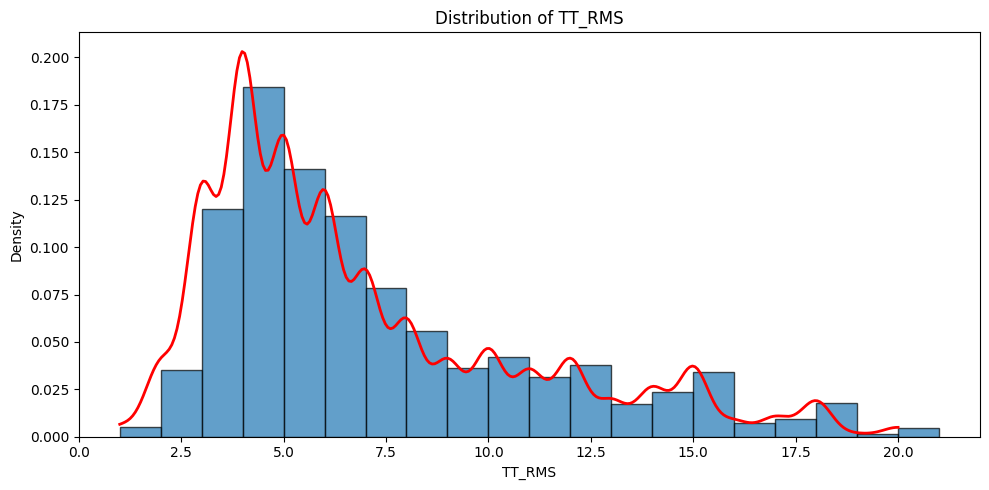

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

vals = df['TT_RMS'].dropna()
ax.hist(vals, bins=range(int(vals.min()), int(vals.max()) + 2), edgecolor='black', alpha=0.7, density=True)

from scipy.stats import gaussian_kde
kde = gaussian_kde(vals)
x = np.linspace(vals.min(), vals.max(), 300)
ax.plot(x, kde(x), color='red', linewidth=2)

ax.set_xlabel('TT_RMS')
ax.set_ylabel('Density')
ax.set_title('Distribution of TT_RMS')
plt.tight_layout()
plt.show()

In [ ]:
room_cols = [c for c in df.columns if any(x in c.upper() for x in ['RM', 'BTH', 'BED', 'KITCHEN'])]
print(room_cols)

['BED_RMS', 'TT_RMS', 'BDRM_COND', 'BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3', 'KITCHEN_TYPE', 'KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3']


#### Validating if total_rooms match or exceed sum of all BTHRM_STYLES, KITHCEN_STYLES, and BED_RMS

In [ ]:
bthrm_cols = ['BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3']
kitchen_cols = ['KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3']

n_bthrm = (df[bthrm_cols] != 'NR - Not Required').sum(axis=1)
n_kitchen = (df[kitchen_cols] != 'NR - Not Required').sum(axis=1)

min_expected = n_bthrm + n_kitchen + df['BED_RMS'].fillna(0)
valid = df['TT_RMS'].notna()
mismatch_mask = valid & (df['TT_RMS'] < min_expected)

print(f"Mismatches: {mismatch_mask.sum()} ({mismatch_mask.sum()/len(df):.2%})")

Mismatches: 29012 (16.99%)


#### The mismatch was suspiciously high, after searching I found that real estates typically do not include bathrooms in their total room counts, so I checked mismatch without including BTHRMS

In [ ]:
kitchen_cols = ['KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3']
n_kitchen = (df[kitchen_cols] != 'NR - Not Required').sum(axis=1)

min_expected = n_kitchen + df['BED_RMS'].fillna(0)
valid = df['TT_RMS'].notna()
mismatch_mask = valid & (df['TT_RMS'] < min_expected)

print(f"Mismatches: {mismatch_mask.sum()} ({mismatch_mask.sum()/len(df):.2%})")

Mismatches: 371 (0.22%)


This confirms the finding, we will drop these 371 rows now as they have inconsistent data

In [ ]:
kitchen_cols = ['KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3']
n_kitchen = (df[kitchen_cols] != 'NR - Not Required').sum(axis=1)

min_expected = n_kitchen + df['BED_RMS'].fillna(0)
valid = df['TT_RMS'].notna()
mismatch_mask = valid & (df['TT_RMS'] < min_expected)
df = df[~mismatch_mask].reset_index(drop=True)
print(f"Rows remaining: {len(df)}")

Rows remaining: 170426


We still have ~20% NaN values for TT_RMS

In [ ]:
print(f"TT_RMS NaN: {df['TT_RMS'].isna().sum()} ({df['TT_RMS'].isna().mean():.2%})")
print(df.loc[df['TT_RMS'].isna(), 'LU'].value_counts().head(15).to_string())

TT_RMS NaN: 35919 (21.08%)
LU
CP         7800
E          7089
RL - RL    5107
C          4526
RC         2833
A          2692
R4         2398
CC         1529
CL         1297
I           418
EA          171
CD           44
R1            6
R3            3
R2            3


In [ ]:
nan_tt = df[df['TT_RMS'].isna()]
res = nan_tt['IS_RES'].value_counts()
print(f"Residential (IS_RES=1):     {res.get(1, 0)} ({res.get(1, 0)/len(nan_tt):.2%})")
print(f"Non-residential (IS_RES=0): {res.get(0, 0)} ({res.get(0, 0)/len(nan_tt):.2%})")

Residential (IS_RES=1):     7554 (21.03%)
Non-residential (IS_RES=0): 28365 (78.97%)


Most rows missing value are non-residential which makes sense, non-residential buildings do not require habitable rooms, so we will fill non-residential NaN values with -1 (NR- Not required) and use mode/mean to fill residential values

In [ ]:
df['TT_RMS'] = df['TT_RMS'].fillna(-1)

In [ ]:
res_tt = df[df['IS_RES'] == 1]['TT_RMS']
res_tt = res_tt[res_tt != -1]  # exclude the -1 fills
print(f"Mean:   {res_tt.mean():.2f}")
print(f"Median: {res_tt.median():.0f}")
print(f"Mode:   {res_tt.mode()[0]:.0f}")
print(f"Variance: {res_tt.var():.2f}")
print(f"Std Dev:  {res_tt.std():.2f}")

Mean:   6.91
Median: 6
Mode:   4
Variance: 15.94
Std Dev:  3.99


Std_dev is ~4 but mean is ~7, imputing with mean would introduce significant noise. Mode is 4 — but that's the most common value, not necessarily representative. With variance of ~16, about 68% of residential properties fall between 3–11 rooms (mean ± 1 std). Imputing everything with 4 would misrepresent the 47% of properties with more than 6 rooms. We can't use mode either

Lets check if TT_RMS count are valid for these residential buildings

In [ ]:
nan_res = df[(df['TT_RMS'] == -1) & (df['IS_RES'] == 1)]

kitchen_cols = ['KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3']
has_kitchen = (nan_res[kitchen_cols] != 'NR - Not Required').any(axis=1)
has_bed = nan_res['BED_RMS'].notna()

print(f"Total residential NaN TT_RMS: {len(nan_res)}")
print(f"Valid BED_RMS:                {has_bed.sum()} ({has_bed.mean():.2%})")
print(f"Valid KITCHEN_STYLE:          {has_kitchen.sum()} ({has_kitchen.mean():.2%})")
print(f"Both valid:                   {(has_bed & has_kitchen).sum()} ({(has_bed & has_kitchen).mean():.2%})")

Total residential NaN TT_RMS: 7554
Valid BED_RMS:                56 (0.74%)
Valid KITCHEN_STYLE:          61 (0.81%)
Both valid:                   55 (0.73%)


In [ ]:
res_neg = df[(df['IS_RES'] == 1) & (df['TT_RMS'] == -1)]
print(f"Total residential TT_RMS=-1: {len(res_neg)}")
print(res_neg[['LU', 'LU_DESC', 'BLDG_TYPE']].value_counts().to_string())

Total residential TT_RMS=-1: 7554
LU  LU_DESC                   BLDG_TYPE                       
R4  APT 4-6 UNITS             111 - APT 4-6 UNITS                 2250
A   APT 7-30 UNITS            112 - APT 7-30 UNITS                1123
RC  RES /COMMERCIAL USE       111 - APT 4-6 UNITS                  429
                              112 - APT 7-30 UNITS                 407
A   SUBSD HOUSING S- 8        125 - SUBSD HOUSING S- 8             290
RC  RES /COMMERCIAL USE       026 - RC: TWO RES UNITS              282
                              027 - RC: THREE RES UNITS            223
A   SUBSD HOUSING S- 8        112 - APT 7-30 UNITS                 189
    APT 7-30 UNITS            113 - APT 31-99 UNITS                155
RC  RES /COMMERCIAL USE       125 - SUBSD HOUSING S- 8             132
A   SUBSD HOUSING S- 8        99 - Vacant                          118
RC  RES /COMMERCIAL USE       113 - APT 31-99 UNITS                117
                              99 - Vacant          

BLDG_TYPE codes follow a pattern:

Letter codes (CL, CV, DK, RM, etc.) → residential building styles
1xx codes → apartment/residential types
0xx codes → mixed-use
3xx codes → commercial
4xx codes → industrial
9xx codes → exempt/institutional
NoBld, 99-Vacant → ambiguous

#### 4xx and exempt code types with TT_RMS = NaN

In [ ]:
res_neg = df[(df['IS_RES'] == 1) & (df['TT_RMS'] == -1)]

# Extract BLDG_TYPE code prefix
bldg_code = res_neg['BLDG_TYPE'].str.extract(r'^(\d+)')[0].astype('Int64')

industrial = res_neg[bldg_code.between(400, 499)]
exempt = res_neg[bldg_code.between(900, 999)]

print(f"4xx (industrial) BLDG_TYPE: {len(industrial)}")
print(industrial['BLDG_TYPE'].value_counts().to_string())

print(f"\n9xx (exempt) BLDG_TYPE: {len(exempt)}")
print(exempt['BLDG_TYPE'].value_counts().to_string())

4xx (industrial) BLDG_TYPE: 1
BLDG_TYPE
407 - MACHINE SHOP (small)    1

9xx (exempt) BLDG_TYPE: 49
BLDG_TYPE
937 - DORMITORY  bd               13
971 - RECTORY, CONVENT            12
950 - APARTMENT BLDG               7
951 - DORMITORY  rm                5
907 - EXEMPT 121A PROP             5
976 - SCHOOL                       2
959 - ASSISTED LIVING/ Elderly     2
945 - ACTIVITY/ Social Center      1
942 - CLASSROOM                    1
904 - PRIV SCHOOL /COLLEGE         1


#### 3xx with TT_RMS = NaN

In [ ]:
commercial = res_neg[bldg_code.between(300, 399)]
print(f"3xx (commercial) BLDG_TYPE: {len(commercial)}")
print(commercial[['LU', 'LU_DESC', 'BLDG_TYPE']].value_counts().to_string())

3xx (commercial) BLDG_TYPE: 104
LU  LU_DESC                   BLDG_TYPE                  
RC  RES /COMMERCIAL USE       320 - RET/WHSL/SERVICE         24
                              319 - STRIP RETAIL/ OFFICE     14
                              343 - OFFICE 1-2 STORY         12
                              344 - OFFICE 3-9 STORY          8
                              326 - RESTAURANT/Cafeteria      5
                              369 - ARTIST STUDIO             5
                              340 - OFFICE (ATTACHED)         4
                              317 - STORAGE WHSE (old)        3
E   BOS HOUSING AUTHOR        343 - OFFICE 1-2 STORY          2
RC  RES /COMMERCIAL USE       328 - FAST FOOD Restaurant      2
A   ELDERLY HOME              304 - NURSING /CONV HOME        2
RC  RES /COMMERCIAL USE       351 - TRAINING /PRIV EDUC       2
A   SUBSD HOUSING S- 8        353 - SOCIAL CLUB               1
RC  RES /COMMERCIAL USE       360 - MUSEUM, GALLERY           1
E   BOS HOUSIN

#### 0xx and 1xx code types with TT_RMS = NaN

In [ ]:
mixed = res_neg[bldg_code.between(0, 99)]
apartments = res_neg[bldg_code.between(100, 199)]

print(f"0xx (mixed-use) BLDG_TYPE: {len(mixed)}")
print(mixed[['LU', 'LU_DESC', 'BLDG_TYPE']].value_counts().to_string())

print(f"\n1xx (apartment) BLDG_TYPE: {len(apartments)}")
print(apartments[['LU', 'LU_DESC', 'BLDG_TYPE']].value_counts().to_string())

0xx (mixed-use) BLDG_TYPE: 1029
LU  LU_DESC              BLDG_TYPE                
RC  RES /COMMERCIAL USE  026 - RC: TWO RES UNITS      282
                         027 - RC: THREE RES UNITS    223
A   SUBSD HOUSING S- 8   99 - Vacant                  118
RC  RES /COMMERCIAL USE  99 - Vacant                  113
                         025 - RC: ONE RES UNIT        69
                         013 - RES /COMMERCIAL USE     69
A   APT 7-30 UNITS       99 - Vacant                   39
E   BOS HOUSING AUTHOR   99 - Vacant                   37
A   SUBSD HOUSING S-202  99 - Vacant                   20
R4  APT 4-6 UNITS        99 - Vacant                   15
A   SUBSD HOUSING S- 8   027 - RC: THREE RES UNITS      7
    ELDERLY HOME         99 - Vacant                    6
RC  RES /COMMERCIAL USE  010 - CONDO MULTI-USE          6
E   BOS HOUSING AUTHOR   025 - RC: ONE RES UNIT         6
A   LUXURY APARTMENT     99 - Vacant                    5
R4  APT 4-6 UNITS        027 - RC: THREE RES UN

In [ ]:
print(f"1xx (apartment) BLDG_TYPE: {len(apartments)}")

1xx (apartment) BLDG_TYPE: 6004


0xx and 1xx types are residential should have BDRMS and TT_RMS, so we will not impute them with -1 (used for non-residential or buildings which shouldn't have habitable room counts), but instead impute them with 0 indicating that they should have habitable room count but they don't

In [ ]:
res_neg = df[(df['IS_RES'] == 1) & (df['TT_RMS'] == -1)]
bldg_code = res_neg['BLDG_TYPE'].str.extract(r'^(\d+)')[0].astype('Int64')

zero_one_xx_idx = res_neg[bldg_code.between(0, 199)].index
df.loc[zero_one_xx_idx, 'TT_RMS'] = 0
print(f"Updated to TT_RMS=0: {len(zero_one_xx_idx)}")

Updated to TT_RMS=0: 7033


In [ ]:
print(f"TT_RMS -1: {(df['TT_RMS'] == -1).sum()}")
print(f"TT_RMS  0: {(df['TT_RMS'] == 0).sum()}")
print(f"TT_RMS NaN: {df['TT_RMS'].isna().sum()}")

TT_RMS -1: 28886
TT_RMS  0: 7033
TT_RMS NaN: 0


### KITCHEN_TYPE, BED_RMS, AC_TYPE, and HEAT_TYPE

In [ ]:
for col in ['KITCHEN_TYPE', 'BED_RMS', 'AC_TYPE', 'HEAT_TYPE']:
    nan_count = df[col].isna().sum()
    print(f"{col}: {nan_count} ({nan_count/len(df):.2%})")

KITCHEN_TYPE: 35867 (21.05%)
BED_RMS: 35863 (21.04%)
AC_TYPE: 35860 (21.04%)
HEAT_TYPE: 35858 (21.04%)


#### Mirror BED_RMS with TT_RMS logic

In [ ]:
res_neg_bed = df[(df['IS_RES'] == 1) & (df['BED_RMS'].isna())]
bldg_code = res_neg_bed['BLDG_TYPE'].str.extract(r'^(\d+)')[0].astype('Int64')

# 0xx/1xx: data not tracked at building level → 0 (Not Available)
zero_one_xx_idx = res_neg_bed[bldg_code.between(0, 199)].index
df.loc[zero_one_xx_idx, 'BED_RMS'] = 0

# Remaining NaN → -1 (Not Required)
df.loc[(df['IS_RES'] == 1) & (df['BED_RMS'].isna()), 'BED_RMS'] = -1

# Non-residential → -1
df.loc[(df['IS_RES'] == 0) & (df['BED_RMS'].isna()), 'BED_RMS'] = -1

print(f"BED_RMS NaN remaining: {df['BED_RMS'].isna().sum()}")

BED_RMS NaN remaining: 0


In [ ]:
print("AC_TYPE unique:")
print(df['AC_TYPE'].value_counts(dropna=False).to_string())

print("\nHEAT_TYPE unique:")
print(df['HEAT_TYPE'].value_counts(dropna=False).to_string())

AC_TYPE unique:
AC_TYPE
N - None           76489
C - Central AC     56070
NaN                35860
D - Ductless AC     2007

HEAT_TYPE unique:
HEAT_TYPE
W - Ht Water/Steam    69303
F - Forced Hot Air    54002
NaN                   35858
E - Electric           5910
P - Heat Pump          4680
S - Space Heat          560
N - None                 82
O - Other                31


#### Non-residential buildings can also have ac and heating system, so we impute NaN with N - None

In [ ]:
df['AC_TYPE'] = df['AC_TYPE'].fillna('N - None')
df['HEAT_TYPE'] = df['HEAT_TYPE'].fillna('N - None')

In [ ]:
print(f"AC_TYPE NaN:   {df['AC_TYPE'].isna().sum()}")
print(f"HEAT_TYPE NaN: {df['HEAT_TYPE'].isna().sum()}")

AC_TYPE NaN:   0
HEAT_TYPE NaN: 0


In [ ]:
print(df['KITCHEN_TYPE'].value_counts(dropna=False).to_string())

KITCHEN_TYPE
O - One Person                 46607
NaN                            35867
1F - 1 Full Eat In Kitchens    29238
F - Full Eat In                24509
2F - 2 Full Eat In Kitchens    16702
3F - 3 Full Eat In Kitchens    12168
P - Pullman                     2592
0F - 0 Full Eat In Kitchens     2587
N - None                         108
4F - 4 Full Eat In Kitchens       47
5F - 5 Full Eat In Kitchens        1


In [ ]:
df['KITCHEN_TYPE'] = df['KITCHEN_TYPE'].fillna('N - None')

In [ ]:
print(f"KITCHEN_TYPE NaN:   {df['KITCHEN_TYPE'].isna().sum()}")

KITCHEN_TYPE NaN:   0


### INT_WALL, INT_COND

In [ ]:
print("INT_WALL unique:")
print(df['INT_WALL'].value_counts(dropna=False).to_string())

print("\nINT_COND unique:")
print(df['INT_COND'].value_counts(dropna=False).to_string())

INT_WALL unique:
INT_WALL
N - Normal         129371
NaN                 35856
E - Elaborate        5131
S - Substandard        65
G - Good                3

INT_COND unique:
INT_COND
A - Average      61925
G - Good         54958
NaN              35855
E - Excellent    16364
F - Fair          1227
P - Poor            97


In [ ]:
for col in ['INT_WALL', 'INT_COND']:
    print(f"\n{col} NaN by LU and LU_DESC:")
    nan_rows = df[df[col].isna()]
    print(nan_rows.groupby(['LU', 'LU_DESC']).size().sort_values(ascending=False).head(20).to_string())


INT_WALL NaN by LU and LU_DESC:
LU       LU_DESC                
CP       CONDO PARKING (RES)        7799
RL - RL  RES LAND (Unusable)        3655
R4       APT 4-6 UNITS              2402
RC       RES /COMMERCIAL USE        2207
E        OTHER EXEMPT BLDG          2083
A        APT 7-30 UNITS             1419
E        CITY OF BOSTON             1364
A        SUBSD HOUSING S- 8          882
E        OTHER PUBLIC LAND           806
CC       RETAIL CONDO                757
RL - RL  RESIDENTIAL LAND            728
         RES ANCILL IMPROVEMT        678
CL       COMMERCIAL LAND             628
RC       COMM MULTI-USE              624
C        RET/WHSL/SERVICE            621
CC       OFFICE CONDO                585
C        STRIP CTR STORES            526
E        COLLEGE (academic)          351
         CHARITABLE Organization     335
C        REPAIR GARAGE               334

INT_COND NaN by LU and LU_DESC:
LU       LU_DESC                
CP       CONDO PARKING (RES)        7799
RL - RL

In [ ]:
nan_combos = df[df['INT_WALL'].isna()][['LU', 'LU_DESC']].drop_duplicates()

for _, row in nan_combos.iterrows():
    mask = (df['LU'] == row['LU']) & (df['LU_DESC'] == row['LU_DESC'])
    non_nan = df[mask & df['INT_WALL'].notna()].shape[0]
    nan = df[mask & df['INT_WALL'].isna()].shape[0]
    if non_nan > 0:
        print(f"{row['LU']} — {row['LU_DESC']}: non-NaN={non_nan}, NaN={nan}")

A — LUXURY APARTMENT: non-NaN=10, NaN=136
R4 — APT 4-6 UNITS: non-NaN=29, NaN=2402
RC — RES /COMMERCIAL USE: non-NaN=73, NaN=2207
A — APT 7-30 UNITS: non-NaN=30, NaN=1419
RC — COMM MULTI-USE: non-NaN=5, NaN=624
E — OTHER EXEMPT BLDG: non-NaN=59, NaN=2083
E — CITY OF BOSTON: non-NaN=8, NaN=1364
E — Commonwealth of Mass: non-NaN=2, NaN=177
A — SUBSD HOUSING S- 8: non-NaN=259, NaN=882
E — PRIV SCHOOL /COLLEGE: non-NaN=6, NaN=169
C — BANK BUILDING: non-NaN=1, NaN=127
E — SCHOOL: non-NaN=1, NaN=204
E — CHURCH, SYNAGOGUE: non-NaN=3, NaN=217
E — ACTIVITY/ Social Center: non-NaN=1, NaN=19
E — BOST REDEVELOP AUTH: non-NaN=85, NaN=208
CC — RETAIL CONDO: non-NaN=5, NaN=757
E — RELIGIOUS Organization: non-NaN=29, NaN=203
EA — EXEMPT 121A PROP: non-NaN=48, NaN=171
CP — CONDO PARKING (RES): non-NaN=1, NaN=7799
CC — COMM  CONDO: non-NaN=7, NaN=138
E — CHARITABLE Organization: non-NaN=71, NaN=335
A — ROOMING HOUSE: non-NaN=1, NaN=78
C — OFFICE (ATTACHED): non-NaN=1, NaN=23
CC — OFFICE CONDO: non-NaN=3

The mixture of non-NaN and NaN values is very diluted for both these features, and the datapoints with NaN are a significant portion of the dataset so we can't drop them either. Lets imput all NaN with "NA - Not available"

In [ ]:
df['INT_WALL'] = df['INT_WALL'].fillna('NA - Not Available')
df['INT_COND'] = df['INT_COND'].fillna('NA - Not Available')

### PROP_VIEW and NUM_PARKING

In [ ]:
print("PROP_VIEW unique:")
print(df['PROP_VIEW'].value_counts(dropna=False).to_string())

print("\nNUM_PARKING unique:")
print(df['NUM_PARKING'].value_counts(dropna=False).to_string())

PROP_VIEW unique:
PROP_VIEW
A - Average      110486
NaN               35823
G - Good          12564
F - Fair           5908
E - Excellent      4525
S - Special         618
P - Poor            502

NUM_PARKING unique:
NUM_PARKING
0.0      58888
NaN      35794
1.0      29820
2.0      22040
3.0       8682
4.0       8180
6.0       3014
5.0       2621
8.0        615
7.0        540
10.0        93
9.0         88
125.0       24
12.0         9
14.0         4
11.0         3
16.0         3
13.0         2
18.0         1
210.0        1
56.0         1
17.0         1
20.0         1
22.0         1


PROP_VIEW and NUM_PARKING are not features we can estimate using other features so impute NaN with "N- None" and 0

In [ ]:
# Imputing PROP_VIEW with NA
df['PROP_VIEW'] = df['PROP_VIEW'].fillna('NA - Not Available')

In [ ]:
# Imputing NUM_PARKING with 0
df['NUM_PARKING'] = df['NUM_PARKING'].fillna(0)

### ROOF_STRUCTURE and ROOF_COVER

In [ ]:
print("ROOF_STRUCTURE unique:")
print(df['ROOF_STRUCTURE'].value_counts(dropna=False).to_string())

print("\nROOF_COVER unique:")
print(df['ROOF_COVER'].value_counts(dropna=False).to_string())

ROOF_STRUCTURE unique:
ROOF_STRUCTURE
F - Flat       64110
G - Gable      43946
NaN            34688
H - Hip        13198
M - Mansard    11769
L - Gambrel     2048
S - Shed         349
O - Other        318

ROOF_COVER unique:
ROOF_COVER
A - Asphalt Shingl    60008
R - Rubber Roof       43469
NaN                   34680
C - Composition       20859
S - Slate             10320
O - Other               753
T - Tile                242
W - Wood Shingle         92
M - Metal                 3


Again these 2 are also features we cannot impute or estimate using other features - fill NaN as "O- Other"

In [ ]:
df['ROOF_STRUCTURE'] = df['ROOF_STRUCTURE'].fillna('O - Other')
df['ROOF_COVER'] = df['ROOF_COVER'].fillna('O - Other')

### Remaining features

#### EXT_COND, EXT_FINISHED, and OVERALL_COND

In [ ]:
for col in ['EXT_COND', 'EXT_FNISHED', 'OVERALL_COND']:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).to_string())


EXT_COND:
EXT_COND
A - Average      73078
G - Good         49995
NaN              34630
E - Excellent    10526
F - Fair          2135
P - Poor            62

EXT_FNISHED:
EXT_FNISHED
B - Brick/Stone       48372
M - Vinyl             40234
NaN                   21479
W - Wood Shake        14745
F - Frame/Clapbrd     11540
C - Cement Board       8923
01 - Brick             7610
A - Asbestos           3586
G - Glass              3557
09 - Wood Siding       1679
S - Stucco             1233
V - Brck/Stn Venr      1127
03 - Poured Concr      1025
10 - Alum/Vinyl         917
P - Asphalt             815
12 - Conc Block         766
U - Alum Siding         754
K - Concrete            516
O - Other               387
02 - Stone              338
11 - Metal Siding       204
04 - Precast Concr      153
06 - Metal/Glass        147
08 - Stucco             144
05 - Concr & Glass       66
15 - Corrug Siding       57
07 - Stone/Marble        32
16 - Cement Board        14
14 - Hollow Tile          5
13 -

EXT_COND can't be estimated so fill NaN with NA- Not available

In [ ]:
df['EXT_COND'] = df['EXT_COND'].fillna('NA - Not Available')

In [ ]:
ext_mode_by_st = df.groupby('ST_NUM')['EXT_FNISHED'].apply(
    lambda x: x.dropna().mode()[0] if x.dropna().shape[0] > 0 else np.nan
)
print(ext_mode_by_st.value_counts(dropna=False).to_string())

EXT_FNISHED
M - Vinyl             802
B - Brick/Stone       641
01 - Brick            485
F - Frame/Clapbrd     138
W - Wood Shake        125
09 - Wood Siding      104
C - Cement Board      101
NaN                    82
03 - Poured Concr      51
12 - Conc Block        48
10 - Alum/Vinyl        34
A - Asbestos           27
02 - Stone             21
S - Stucco             17
08 - Stucco            13
G - Glass              10
11 - Metal Siding      10
04 - Precast Concr      6
U - Alum Siding         6
P - Asphalt             5
K - Concrete            3
O - Other               3
V - Brck/Stn Venr       2
05 - Concr & Glass      1
15 - Corrug Siding      1
16 - Cement Board       1
06 - Metal/Glass        1
14 - Hollow Tile        1


In [ ]:
ext_mode_by_st = df.groupby('ST_NUM')['EXT_FNISHED'].apply(
    lambda x: x.dropna().mode()[0] if x.dropna().shape[0] > 0 else np.nan
)
print(ext_mode_by_st.to_string())

ST_NUM
0.0               01 - Brick
1.0                G - Glass
2.0          B - Brick/Stone
3.0                M - Vinyl
4.0          B - Brick/Stone
5.0                M - Vinyl
6.0                M - Vinyl
7.0                M - Vinyl
8.0          B - Brick/Stone
9.0          B - Brick/Stone
10.0               M - Vinyl
11.0               M - Vinyl
12.0               M - Vinyl
13.0               M - Vinyl
14.0               M - Vinyl
15.0               M - Vinyl
16.0               M - Vinyl
17.0               M - Vinyl
18.0               M - Vinyl
19.0               M - Vinyl
20.0               M - Vinyl
21.0         B - Brick/Stone
22.0               M - Vinyl
23.0               M - Vinyl
24.0               M - Vinyl
25.0         B - Brick/Stone
26.0               M - Vinyl
27.0               M - Vinyl
28.0               M - Vinyl
29.0               M - Vinyl
30.0               M - Vinyl
31.0               M - Vinyl
32.0               M - Vinyl
33.0               M - Vinyl
34.0   

In [ ]:
loc_cols = [c for c in df.columns if any(x in c.upper() for x in ['ST_', 'MAIL', 'ZIP', 'CITY', 'AREA', 'WARD', 'NEIGHBOR'])]
print(loc_cols)

['ST_NUM', 'ST_NAME', 'CITY', 'ZIP_CODE', 'MAIL_CITY', 'MAIL_STATE', 'MAIL_ZIP_CODE', 'GROSS_AREA', 'LIVING_AREA']


In [ ]:
for level in [['ST_NUM', 'ST_NAME'], ['ST_NAME', 'ZIP_CODE'], ['ZIP_CODE'], ['CITY']]:
    groups = df.groupby(level)
    nan_pct = df.groupby(level)['EXT_FNISHED'].apply(lambda x: x.isna().mean())
    group_sizes = groups.size()
    nuniq = df.groupby(level)['EXT_FNISHED'].apply(lambda x: x.dropna().nunique())
    
    print(f"\nLevel {level}:")
    print(f"  Total groups: {len(groups)}")
    print(f"  Avg group size: {group_sizes.mean():.1f}")
    print(f"  Avg unique values per group: {nuniq.mean():.2f}")
    print(f"  Avg NaN % per group: {nan_pct.mean():.2%}")
    print(f"  Groups with 0% NaN: {(nan_pct == 0).sum()}")
    print(f"  Groups with 100% NaN: {(nan_pct == 1).sum()}")
    print(f"  Groups with mixed NaN: {((nan_pct > 0) & (nan_pct < 1)).sum()}")


Level ['ST_NUM', 'ST_NAME']:
  Total groups: 90975
  Avg group size: 1.8
  Avg unique values per group: 0.96
  Avg NaN % per group: 5.50%
  Groups with 0% NaN: 85184
  Groups with 100% NaN: 4466
  Groups with mixed NaN: 1325

Level ['ST_NAME', 'ZIP_CODE']:
  Total groups: 5120
  Avg group size: 33.3
  Avg unique values per group: 3.45
  Avg NaN % per group: 19.76%
  Groups with 0% NaN: 1939
  Groups with 100% NaN: 432
  Groups with mixed NaN: 2749

Level ['ZIP_CODE']:
  Total groups: 38
  Avg group size: 4484.8
  Avg unique values per group: 15.47
  Avg NaN % per group: 13.63%
  Groups with 0% NaN: 7
  Groups with 100% NaN: 1
  Groups with mixed NaN: 30

Level ['CITY']:
  Total groups: 19
  Avg group size: 8969.6
  Avg unique values per group: 18.89
  Avg NaN % per group: 11.02%
  Groups with 0% NaN: 3
  Groups with 100% NaN: 0
  Groups with mixed NaN: 16


We cannot use mode of EXT_FINISHED in each area to impute NaN values in EXT_FINISHED, the groups are too noisy, so we impute NaN with NA here as well

In [ ]:
df['EXT_FNISHED'] = df['EXT_FNISHED'].fillna('NA - Not Available')

In [ ]:
print(df['OVERALL_COND'].value_counts(dropna=False).to_string())

OVERALL_COND
A - Average       122770
G - Good           34465
NaN                 7347
VG - Very Good      1787
E - Excellent       1661
EX - Excellent      1231
F - Fair            1042
P - Poor              98
US - Unsound          15
VP - Very Poor        10


In [ ]:
nan_by_zip = df[df['OVERALL_COND'].isna()].groupby('ZIP_CODE').size()
nan_zips = nan_by_zip.index

zip_mode = df[df['ZIP_CODE'].isin(nan_zips)].groupby('ZIP_CODE')['OVERALL_COND'].apply(
    lambda x: x.dropna().mode()[0] if x.dropna().shape[0] > 0 else np.nan
)

print("ZIP_CODE | NaN count | Mode")
for zip_code in nan_zips:
    print(f"{zip_code}: NaN={nan_by_zip[zip_code]}, mode={zip_mode.get(zip_code, 'N/A')}")

ZIP_CODE | NaN count | Mode
2108.0: NaN=10, mode=A - Average
2109.0: NaN=24, mode=A - Average
2110.0: NaN=45, mode=A - Average
2111.0: NaN=77, mode=A - Average
2113.0: NaN=112, mode=A - Average
2114.0: NaN=77, mode=A - Average
2115.0: NaN=28, mode=A - Average
2116.0: NaN=104, mode=A - Average
2118.0: NaN=305, mode=A - Average
2119.0: NaN=278, mode=A - Average
2120.0: NaN=118, mode=A - Average
2121.0: NaN=121, mode=A - Average
2122.0: NaN=400, mode=A - Average
2124.0: NaN=361, mode=A - Average
2125.0: NaN=520, mode=A - Average
2126.0: NaN=95, mode=A - Average
2127.0: NaN=1504, mode=A - Average
2128.0: NaN=636, mode=A - Average
2129.0: NaN=211, mode=A - Average
2130.0: NaN=955, mode=A - Average
2131.0: NaN=482, mode=A - Average
2132.0: NaN=137, mode=A - Average
2134.0: NaN=44, mode=A - Average
2135.0: NaN=255, mode=A - Average
2136.0: NaN=157, mode=A - Average
2210.0: NaN=204, mode=A - Average
2215.0: NaN=83, mode=A - Average
2446.0: NaN=3, mode=A - Average
2467.0: NaN=1, mode=A - Averag

In [ ]:
print(f"Mode:   {df['OVERALL_COND'].mode()[0]}")
print(f"NaN:    {df['OVERALL_COND'].isna().sum()} ({df['OVERALL_COND'].isna().mean():.2%})")
print(f"\nValue distribution:")
print((df['OVERALL_COND'].value_counts(normalize=True) * 100).round(2).to_string())

Mode:   A - Average
NaN:    7347 (4.31%)

Value distribution:
OVERALL_COND
A - Average       75.28
G - Good          21.13
VG - Very Good     1.10
E - Excellent      1.02
EX - Excellent     0.75
F - Fair           0.64
P - Poor           0.06
US - Unsound       0.01
VP - Very Poor     0.01


##### Imputing OVERALL_COND NaN with above distribution

In [ ]:
dist = df['OVERALL_COND'].value_counts(normalize=True)
nan_mask = df['OVERALL_COND'].isna()

df.loc[nan_mask, 'OVERALL_COND'] = np.random.choice(
    dist.index, size=nan_mask.sum(), p=dist.values
)

print(f"OVERALL_COND NaN remaining: {df['OVERALL_COND'].isna().sum()}")
print(df['OVERALL_COND'].value_counts(normalize=True).mul(100).round(2).to_string())

OVERALL_COND NaN remaining: 0
OVERALL_COND
A - Average       75.28
G - Good          21.14
VG - Very Good     1.10
E - Excellent      1.02
EX - Excellent     0.76
F - Fair           0.64
P - Poor           0.06
US - Unsound       0.01
VP - Very Poor     0.01


#### MAILING_STATE, MAILING_ZIP_CODE, and BLDG_TYPE

In [ ]:
before = len(df)
df = df.dropna(subset=['BLDG_TYPE', 'MAIL_STATE', 'MAIL_ZIP_CODE']).reset_index(drop=True)
print(f"Dropped: {before - len(df)} rows")
print(f"Rows remaining: {len(df)}")

Dropped: 2687 rows
Rows remaining: 167739


#### LIVING_AREA, GROSS_AREA, LAND_SF, and RES_FLOOR

In [ ]:
for col in ['LIVING_AREA', 'GROSS_AREA', 'LAND_SF', 'RES_FLOOR']:
    nan = df[col].isna().sum()
    print(f"{col}: {nan} ({nan/len(df):.2%})")

LIVING_AREA: 19267 (11.49%)
GROSS_AREA: 19258 (11.48%)
LAND_SF: 6575 (3.92%)
RES_FLOOR: 29303 (17.47%)


No reliable feature method to impute nmumber of floors, imputing NaN with '-1'

In [ ]:
df['RES_FLOOR'] = df['RES_FLOOR'].fillna(-1)

In [ ]:
for col in ['LIVING_AREA', 'GROSS_AREA', 'LAND_SF', 'RES_FLOOR']:
    print(f"\n{col}:")
    print(df[col].describe())

print("\nBLDG_TYPE NaN count:", df['BLDG_TYPE'].isna().sum())
print("\nMAIL_STATE unique:")
print(df['MAIL_STATE'].value_counts(dropna=False).head(10).to_string())
print("\nMAIL_ZIP_CODE NaN:", df['MAIL_ZIP_CODE'].isna().sum())


LIVING_AREA:
count    1.484720e+05
mean     4.333462e+03
std      3.828819e+04
min      2.000000e+00
25%      9.430000e+02
50%      1.475000e+03
75%      2.578000e+03
max      6.982322e+06
Name: LIVING_AREA, dtype: float64

GROSS_AREA:
count    1.484810e+05
mean     5.305232e+03
std      4.101148e+04
min      3.000000e+00
25%      9.650000e+02
50%      2.040000e+03
75%      3.972000e+03
max      6.982322e+06
Name: GROSS_AREA, dtype: float64

LAND_SF:
count     161164
unique     16279
top        5,000
freq        2233
Name: LAND_SF, dtype: object

RES_FLOOR:
count    138436.000000
mean          1.746070
std           0.865288
min           0.000000
25%           1.000000
50%           2.000000
75%           2.000000
max          46.000000
Name: RES_FLOOR, dtype: float64

BLDG_TYPE NaN count: 0

MAIL_STATE unique:
MAIL_STATE
MA    159807
FL      1269
NY      1128
CA       966
NH       779
TX       511
CT       444
RI       275
NJ       271
ME       220

MAIL_ZIP_CODE NaN: 0


High variance — mean (~4300) is 3x the median (~1473) due to extreme outliers (max 6.9M). Imputing with mean/median would be unreliable.

In [ ]:
both_nan = df['LIVING_AREA'].isna() & df['GROSS_AREA'].isna()
only_living = df['LIVING_AREA'].isna() & df['GROSS_AREA'].notna()
only_gross = df['GROSS_AREA'].isna() & df['LIVING_AREA'].notna()

print(f"Both NaN:        {both_nan.sum()}")
print(f"Only LIVING_AREA NaN: {only_living.sum()}")
print(f"Only GROSS_AREA NaN:  {only_gross.sum()}")

Both NaN:        19258
Only LIVING_AREA NaN: 9
Only GROSS_AREA NaN:  0


Missing values in LIVING_AREA and GROSS_AREA almost perfectly overlap

In [ ]:
print(df[both_nan]['LU'].value_counts().to_string())

LU
CP         6962
RL - RL    4887
E          4757
C          1075
CL          439
A           372
RC          262
CC          215
I           141
R4           73
EA           72
AH            3


Clear pattern:

CP, RL-RL, CL (~12k): land/parking — no building, area = 0 makes sense
E, C, CC, I, EA, AH (~6k): non-residential — fill with 0 or impute
A, RC, R4 (~700): residential buildings — should have area, can try to impute by LU median

In [ ]:
for col in ['LIVING_AREA', 'GROSS_AREA']:
    lu_stats = df.groupby('LU')[col].agg(['median', 'std', 'count'])
    print(f"\n{col} by LU:")
    print(lu_stats.round(2).to_string())


LIVING_AREA by LU:
          median        std  count
LU                                
A         8173.0   41524.42   2592
AH           NaN        NaN      0
C         5900.0  129732.31   3377
CC        1269.5   24971.34   1142
CD         967.0     550.80  73353
CL        3902.0  261980.56     20
CP       32564.0    9804.38     36
E        10560.0  222025.55   2514
EA       15382.5   91898.59    144
I         9108.0   33368.22    269
R1        1620.0     794.36  30237
R2        2600.0     713.28  16555
R3        3519.0     843.66  13276
R4        4251.0    6200.84   2349
RC        5102.0   73765.01   2608
RL - RL      NaN        NaN      0

GROSS_AREA by LU:
          median        std  count
LU                                
A        10000.0   44686.70   2593
AH           NaN        NaN      0
C         8060.0  141202.44   3379
CC        1273.0   24960.45   1143
CD         971.0     574.08  73354
CL        5197.5  306347.27     20
CP       39076.0   12081.15     36
E        13262.0

Std_dev is too high cannot impute with median

In [ ]:
# Step 1: land/parking/no-building → 0
no_bldg = ['CP', 'RL - RL', 'CL']
for col in ['LIVING_AREA', 'GROSS_AREA']:
    df.loc[df['LU'].isin(no_bldg) & df[col].isna(), col] = 0

# Step 2: reliable LU types → impute by LU median
reliable_lu = ['CD', 'R1', 'R2', 'R3', 'R4']
for col in ['LIVING_AREA', 'GROSS_AREA']:
    lu_median = df[df['LU'].isin(reliable_lu)].groupby('LU')[col].median()
    mask = df[col].isna() & df['LU'].isin(reliable_lu)
    df.loc[mask, col] = df.loc[mask, 'LU'].map(lu_median)

# Step 3: remaining high-variance types → -1
for col in ['LIVING_AREA', 'GROSS_AREA']:
    df.loc[df[col].isna(), col] = -1

print(f"LIVING_AREA NaN: {df['LIVING_AREA'].isna().sum()}")
print(f"GROSS_AREA NaN:  {df['GROSS_AREA'].isna().sum()}")

LIVING_AREA NaN: 0
GROSS_AREA NaN:  0


## Checking if any features remain with NaN values

In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) == 0:
    print("No NaN values remaining in any feature")
else:
    print(f"Features with NaN values:")
    for col, count in missing.items():
        print(f"  {col}: {count} ({count/len(df):.2%})")

Features with NaN values:
  CM_ID: 85493 (50.97%)
  ST_NUM: 7852 (4.68%)
  LAND_SF: 6575 (3.92%)
  CITY: 3 (0.00%)
  ZIP_CODE: 3 (0.00%)
  FIREPLACES: 3 (0.00%)


In [ ]:
# Drop CM_ID column
df = df.drop(columns=['CM_ID'])

# Drop rows with missing CITY, ZIP_CODE, FIREPLACES
df = df.dropna(subset=['CITY', 'ZIP_CODE', 'FIREPLACES']).reset_index(drop=True)

print(f"Rows remaining: {len(df)}")
print(f"NaN remaining: {df.isna().sum().sum()}")

Rows remaining: 167731
NaN remaining: 14425


In [ ]:
print(df['LAND_SF'].describe())
print(f"\nNaN: {df['LAND_SF'].isna().sum()} ({df['LAND_SF'].isna().mean():.2%})")
print(f"\nNaN by LU:")
print(df[df['LAND_SF'].isna()]['LU'].value_counts().to_string())

count     161158
unique     16277
top        5,000
freq        2233
Name: LAND_SF, dtype: object

NaN: 6573 (3.92%)

NaN by LU:
LU
CP         5964
C           235
E           192
I            47
R4           45
RL - RL      18
A            18
CC           17
RC           13
CL           12
EA           11
R3            1


In [ ]:
print(df['LAND_SF'].value_counts(dropna=False).head(30).to_string())

LAND_SF
NaN      6573
5,000    2233
4,000    1260
6,000     798
2,500     738
4,500     618
5,500     575
3,600     471
3,200     455
3,000     426
1,000     304
780       296
2,000     294
1,100     284
4,800     272
6,250     270
1,050     269
800       264
1,200     261
7,500     257
700       248
600       247
760       244
4,200     239
900       234
690       229
1,500     228
1,250     227
625       223
6,600     215


In [ ]:
df['LAND_SF'] = pd.to_numeric(df['LAND_SF'].astype(str).str.replace(',', ''), errors='coerce')

print("LAND_SF by LU (NaN rows):")
nan_lu = df[df['LAND_SF'].isna()]['LU'].value_counts()

for lu in nan_lu.index:
    stats = df[df['LU'] == lu]['LAND_SF'].agg(['median', 'std', 'count'])
    print(f"  {lu}: NaN={nan_lu[lu]}, median={stats['median']:.0f}, std={stats['std']:.0f}, count={stats['count']:.0f}")

LAND_SF by LU (NaN rows):
  CP: NaN=5964, median=166, std=220, count=1032
  C: NaN=235, median=6705, std=109397, count=4219
  E: NaN=192, median=5947, std=1291434, count=7080
  I: NaN=47, median=13730, std=115796, count=363
  R4: NaN=45, median=2835, std=7050, count=2377
  RL - RL: NaN=18, median=2925, std=16229, count=4869
  A: NaN=18, median=4480, std=53122, count=2945
  CC: NaN=17, median=1230, std=24704, count=1339
  RC: NaN=13, median=2688, std=63486, count=2860
  CL: NaN=12, median=3749, std=100180, count=447
  EA: NaN=11, median=15024, std=57347, count=205
  R3: NaN=1, median=3401, std=3468, count=13275


In [ ]:
df.loc[df['LAND_SF'].isna(), 'LAND_SF'] = -1
print(f"LAND_SF NaN remaining: {df['LAND_SF'].isna().sum()}")

LAND_SF NaN remaining: 0


Even though st_num has ~4% missing values, we can drop the entire column as it is location identifier which is already done with ST_NAME

In [ ]:
df = df.drop(columns=['ST_NUM'])

In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) == 0:
    print("No NaN values remaining in any feature")
else:
    print(f"Features with NaN values:")
    for col, count in missing.items():
        print(f"  {col}: {count} ({count/len(df):.2%})")

No NaN values remaining in any feature
